# Sensorimotor EEG ERD Analysis

Decoding motor intent from sensorimotor EEG using spectral and time–frequency analysis.

**Goal:** Quantify event-related desynchronization (ERD) in the mu (8–12 Hz) and beta (13–30 Hz) bands over sensorimotor cortex (C3/Cz/C4) during motor task events.

This notebook loads multiple subjects from the EEGBCI dataset, preprocesses their EEG data, extracts epochs for rest and motor-task conditions, and compares spectral power across conditions using PSD, time-frequency analysis, and ERD computation.

## Load Dataset (EEGBCI / PhysioNet)

We use the PhysioNet EEG Motor Movement/Imagery dataset via MNE's EEGBCI loader.

The dataset is stored in EDF format, and event markers typically include:
- **T0** = rest
- **T1** = one motor task
- **T2** = another motor task

In this notebook, we average across multiple subjects to make the results more stable and statistically meaningful.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import re
from mne.datasets import eegbci
from mne.io import read_raw_edf
from scipy.stats import ttest_rel

## Subject Selection and Storage Lists

We define a list of subjects and initialize lists that will store epochs for each condition across subjects.

In [2]:
subjects = [1, 2, 3, 4, 5, 6]
runs = [6]   # motor imagery run

all_epochs_T0 = []
all_epochs_T1 = []
all_epochs_T2 = []
all_epochs_task = []

## Load, Inspect, and Preprocess Each Subject

For each subject, we:
1. Load the EEG file
2. Clean channel names
3. Set the electrode montage
4. Filter the signal from 1–40 Hz
5. Extract event annotations
6. Create epochs from −2 to 2 s around each event
7. Store rest and task epochs for later averaging

In [3]:
for s in subjects:
    print(f"\nProcessing subject {s}...")
    
    # load file
    files = eegbci.load_data(s, runs)
    raw = read_raw_edf(files[0], preload=True, verbose=False)

    # show information for first subject only
    if s == subjects[0]:
        print(raw.info)
        print("Number of channels:", len(raw.ch_names))
        print("First 15 channels:", raw.ch_names[:15])

    # clean channel names
    raw.rename_channels(lambda ch: re.sub(r'[\.\s]', '', ch))

    # set montage
    raw.set_montage("standard_1020", on_missing="ignore")

    # confirm motor cortex electrodes
    roi = ["C3", "Cz", "C4"]
    if s == subjects[0]:
        print("ROI present:", {ch: (ch in raw.ch_names) for ch in roi})

    # bandpass filter
    raw_filt = raw.copy().filter(l_freq=1.0, h_freq=40.0, verbose=False)

    # extract events
    events, event_id = mne.events_from_annotations(raw_filt, verbose=False)
    if s == subjects[0]:
        print("event_id mapping:", event_id)

    # create epochs
    epochs = mne.Epochs(
        raw_filt,
        events,
        event_id=event_id,
        tmin=-2.0,
        tmax=2.0,
        baseline=(-2.0, -1.0),
        picks="eeg",
        preload=True,
        verbose=False
    )

    epochs_T0 = epochs["T0"]
    epochs_T1 = epochs["T1"]
    epochs_T2 = epochs["T2"]
    epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])

    print("Epoch counts:", len(epochs_T0), len(epochs_T1), len(epochs_T2))

    all_epochs_T0.append(epochs_T0)
    all_epochs_T1.append(epochs_T1)
    all_epochs_T2.append(epochs_T2)
    all_epochs_task.append(epochs_task)


Processing subject 1...


/Users/keeratkaur/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: 3 items (dict)
>
Number of channels: 64
First 15 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.']
ROI present: {'C3': True, 'Cz': True, 'C4': True}
event_id mapping: {'T0': 1, 'T1': 2, 'T2': 3}
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
Epoch counts: 14 7 8

Processing subject 2...


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_13350/984975464.py:49: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)


...

/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_13350/984975464.py:49: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


Epoch counts: 14 8 7

Processing subject 5...
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_13350/984975464.py:49: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


Epoch counts: 14 7 8

Processing subject 6...
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
Epoch counts: 14 7 8


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_13350/984975464.py:49: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


## Power Spectral Density (PSD): Rest vs Task

We compute Welch PSD for C3, Cz, and C4 in each subject, then average across subjects to compare oscillatory power during rest vs task.

The mu (8–12 Hz) and beta (13–30 Hz) bands are highlighted because ERD is expected in these ranges during motor activity.

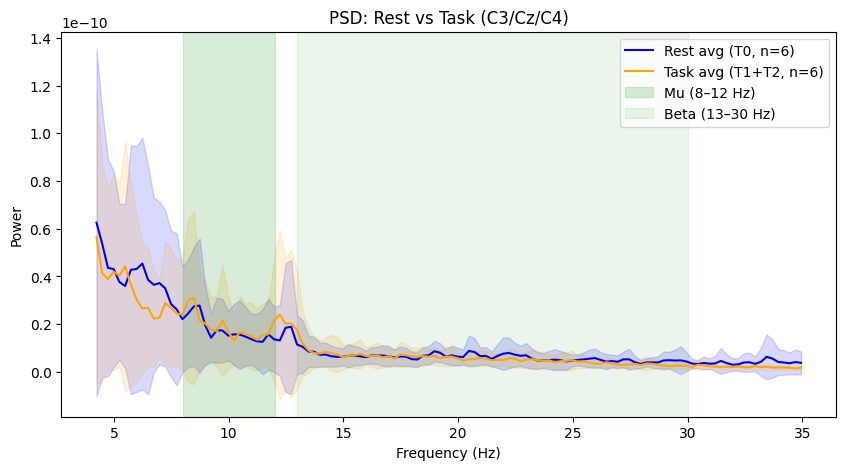

In [4]:
roi = ["C3", "Cz", "C4"]

all_rest_psd = []
all_task_psd = []

for i in range(len(subjects)):
    psd_rest = all_epochs_T0[i].copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35, verbose=False)
    psd_task = all_epochs_task[i].copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35, verbose=False)

    all_rest_psd.append(psd_rest.get_data().mean(axis=(0, 1)))
    all_task_psd.append(psd_task.get_data().mean(axis=(0, 1)))
    freqs = psd_rest.freqs

all_rest_psd = np.array(all_rest_psd)
all_task_psd = np.array(all_task_psd)

rest_mean = all_rest_psd.mean(axis=0)
rest_std = all_rest_psd.std(axis=0)
task_mean = all_task_psd.mean(axis=0)
task_std = all_task_psd.std(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(freqs, rest_mean, label="Rest avg (T0, n=6)", color="blue")
plt.fill_between(freqs, rest_mean - rest_std, rest_mean + rest_std, alpha=0.15, color="blue")
plt.plot(freqs, task_mean, label="Task avg (T1+T2, n=6)", color="orange")
plt.fill_between(freqs, task_mean - task_std, task_mean + task_std, alpha=0.15, color="orange")
plt.axvspan(8, 12, alpha=0.15, color="green", label="Mu (8–12 Hz)")
plt.axvspan(13, 30, alpha=0.08, color="green", label="Beta (13–30 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("PSD: Rest vs Task (C3/Cz/C4)")
plt.legend()
plt.show()

## Lateralization Check: C3 vs C4 for T1 vs T2

Motor activity is often contralateral:
- left-hand motor imagery should produce stronger changes over the right hemisphere
- right-hand motor imagery should produce stronger changes over the left hemisphere

We compare PSD at C3 and C4 across T1 and T2 to look for this lateralization.

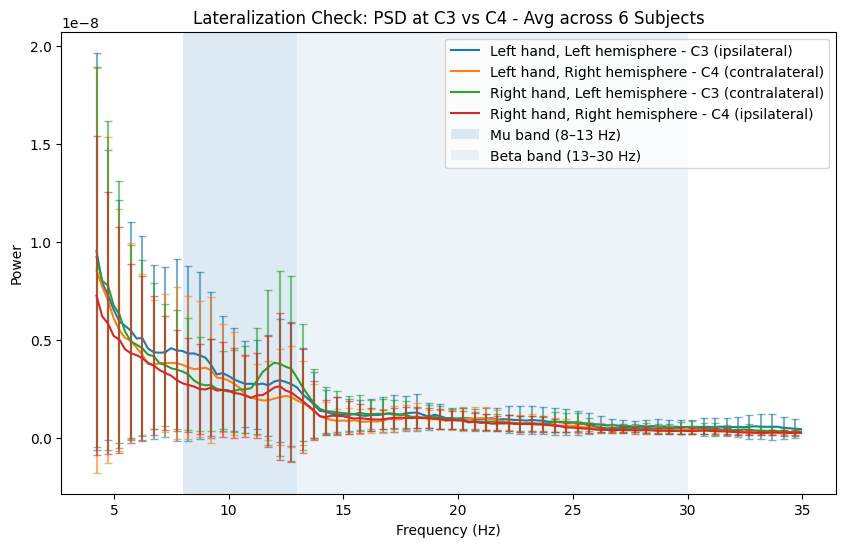

In [5]:
c3_T1 = np.array([all_epochs_T1[i].copy().pick(["C3"]).compute_psd(fmin=4, fmax=35, verbose=False).get_data().mean(axis=(0, 1)) for i in range(len(subjects))])
c4_T1 = np.array([all_epochs_T1[i].copy().pick(["C4"]).compute_psd(fmin=4, fmax=35, verbose=False).get_data().mean(axis=(0, 1)) for i in range(len(subjects))])
c3_T2 = np.array([all_epochs_T2[i].copy().pick(["C3"]).compute_psd(fmin=4, fmax=35, verbose=False).get_data().mean(axis=(0, 1)) for i in range(len(subjects))])
c4_T2 = np.array([all_epochs_T2[i].copy().pick(["C4"]).compute_psd(fmin=4, fmax=35, verbose=False).get_data().mean(axis=(0, 1)) for i in range(len(subjects))])

freqs_lat = all_epochs_T1[0].copy().pick(["C3"]).compute_psd(fmin=4, fmax=35, verbose=False).freqs

c3_T1_avg, c3_T1_std = c3_T1.mean(axis=0), c3_T1.std(axis=0)
c4_T1_avg, c4_T1_std = c4_T1.mean(axis=0), c4_T1.std(axis=0)
c3_T2_avg, c3_T2_std = c3_T2.mean(axis=0), c3_T2.std(axis=0)
c4_T2_avg, c4_T2_std = c4_T2.mean(axis=0), c4_T2.std(axis=0)

step = 2
idx = np.arange(0, len(freqs_lat), step)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freqs_lat, c3_T1_avg, label="Left hand, Left hemisphere - C3 (ipsilateral)", color="tab:blue")
ax.errorbar(freqs_lat[idx], c3_T1_avg[idx], yerr=c3_T1_std[idx], fmt="none", color="tab:blue", capsize=3, alpha=0.6)

ax.plot(freqs_lat, c4_T1_avg, label="Left hand, Right hemisphere - C4 (contralateral)", color="tab:orange")
ax.errorbar(freqs_lat[idx], c4_T1_avg[idx], yerr=c4_T1_std[idx], fmt="none", color="tab:orange", capsize=3, alpha=0.6)

ax.plot(freqs_lat, c3_T2_avg, label="Right hand, Left hemisphere - C3 (contralateral)", color="tab:green")
ax.errorbar(freqs_lat[idx], c3_T2_avg[idx], yerr=c3_T2_std[idx], fmt="none", color="tab:green", capsize=3, alpha=0.6)

ax.plot(freqs_lat, c4_T2_avg, label="Right hand, Right hemisphere - C4 (ipsilateral)", color="tab:red")
ax.errorbar(freqs_lat[idx], c4_T2_avg[idx], yerr=c4_T2_std[idx], fmt="none", color="tab:red", capsize=3, alpha=0.6)

ax.axvspan(8, 13, alpha=0.15, label="Mu band (8–13 Hz)")
ax.axvspan(13, 30, alpha=0.08, label="Beta band (13–30 Hz)")
ax.set_title("Lateralization Check: PSD at C3 vs C4 - Avg across 6 Subjects")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.legend(loc="upper right")
plt.show()

## Time–Frequency Analysis (Morlet Wavelets)

We compute time–frequency representations for C3, Cz, and C4 to visualize how oscillatory power changes over time during the motor task.

We use baseline normalization from −2 to −1 s so decreases in mu/beta power appear as ERD.

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


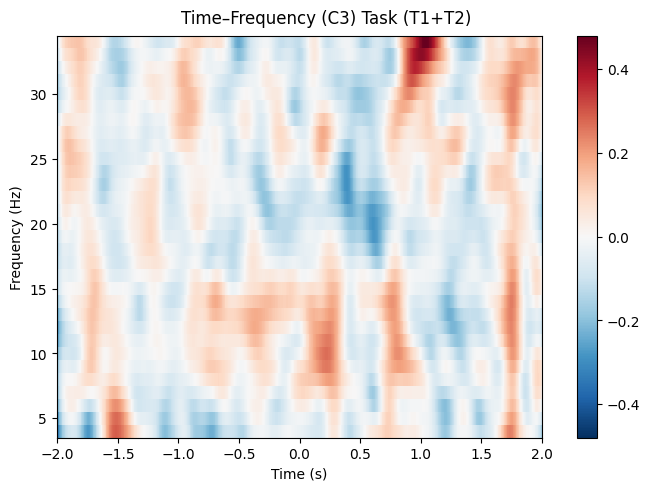

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


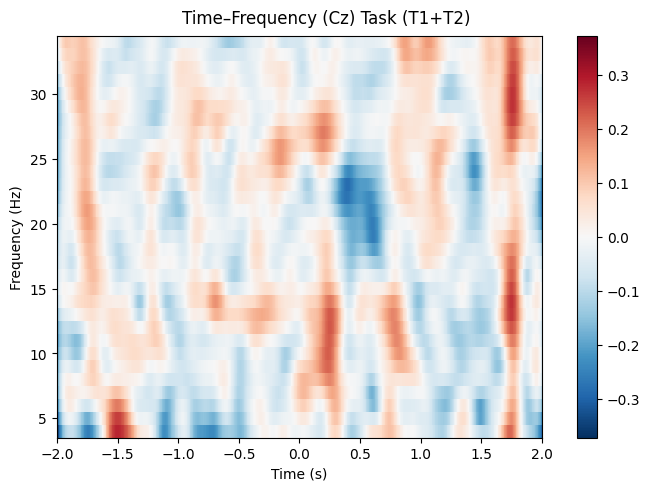

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


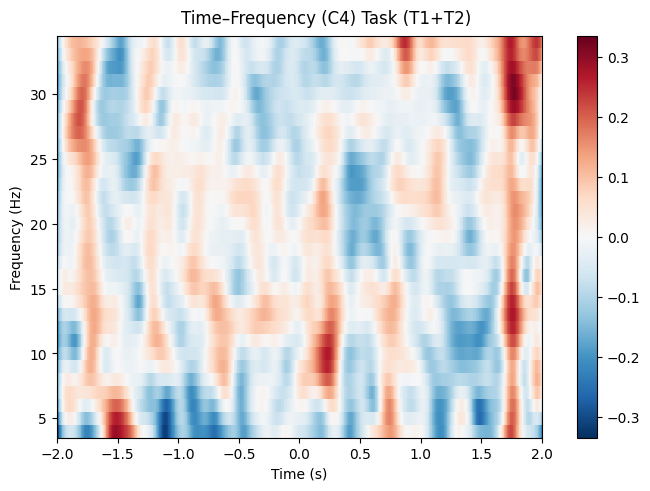

In [6]:
for ch in ["C3", "Cz", "C4"]:
    power = mne.time_frequency.tfr_morlet(
        all_epochs_task[0].copy().pick([ch]),
        freqs=np.arange(4, 35, 1),
        n_cycles=np.arange(4, 35, 1) / 2,
        return_itc=False,
        average=True,
        verbose=False
    )

    power.data = np.mean([
        mne.time_frequency.tfr_morlet(
            all_epochs_task[i].copy().pick([ch]),
            freqs=np.arange(4, 35, 1),
            n_cycles=np.arange(4, 35, 1) / 2,
            return_itc=False,
            average=True,
            verbose=False
        ).data
        for i in range(len(subjects))
    ], axis=0)

    power.plot(baseline=(-2, -1), mode="logratio", title=f"Time–Frequency ({ch}) Task (T1+T2)")

## ERD Computation (Mu and Beta)

We compute event-related desynchronization (ERD) as the percent decrease in band power during a task window relative to baseline:

$$
ERD(\%) = \frac{P_{\text{baseline}} - P_{\text{task}}}{P_{\text{baseline}}} \times 100
$$

Baseline window: **−2 to −1 s**  
Task window: **0 to 1 s**

In [7]:
def bandpower(epochs_obj, fmin, fmax, tmin, tmax, roi=("C3", "Cz", "C4")):
    ep = epochs_obj.copy().pick(list(roi)).crop(tmin=tmin, tmax=tmax)
    psd = ep.compute_psd(method="welch", fmin=fmin, fmax=fmax, verbose=False)
    return psd.get_data().mean(axis=(1, 2))

base_win = (-2.0, -1.0)
task_win = (0.0, 1.0)

mu_base = np.concatenate([bandpower(all_epochs_task[i], 8, 12, *base_win) for i in range(len(subjects))])
mu_task = np.concatenate([bandpower(all_epochs_task[i], 8, 12, *task_win) for i in range(len(subjects))])

beta_base = np.concatenate([bandpower(all_epochs_task[i], 13, 30, *base_win) for i in range(len(subjects))])
beta_task = np.concatenate([bandpower(all_epochs_task[i], 13, 30, *task_win) for i in range(len(subjects))])

erd_mu = ((mu_base.mean() - mu_task.mean()) / mu_base.mean()) * 100
erd_beta = ((beta_base.mean() - beta_task.mean()) / beta_base.mean()) * 100

print(f"ERD mu (8–12 Hz): {erd_mu:.2f}%")
print(f"ERD beta (13–30 Hz): {erd_beta:.2f}%")

ERD mu (8–12 Hz): 1.54%
ERD beta (13–30 Hz): 10.30%


## Statistical Test: Baseline vs Task Bandpower

We run paired t-tests comparing baseline vs task bandpower within epochs for mu and beta bands. This provides a quantitative check of whether the ERD trend is statistically reliable.

In [8]:
t_mu = ttest_rel(mu_base, mu_task)
t_beta = ttest_rel(beta_base, beta_task)

print("Mu band paired t-test:", t_mu)
print("Beta band paired t-test:", t_beta)

Mu band paired t-test: TtestResult(statistic=0.13795157055876062, pvalue=0.89059032640208, df=89)
Beta band paired t-test: TtestResult(statistic=1.716615653366799, pvalue=0.08952798751908239, df=89)


## Time–Frequency Analysis (Morlet Wavelets)

We compute a time–frequency representation to visualize task-related power changes over time.
We use baseline normalization (-2 to -1 s) and log-ratio scaling.

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


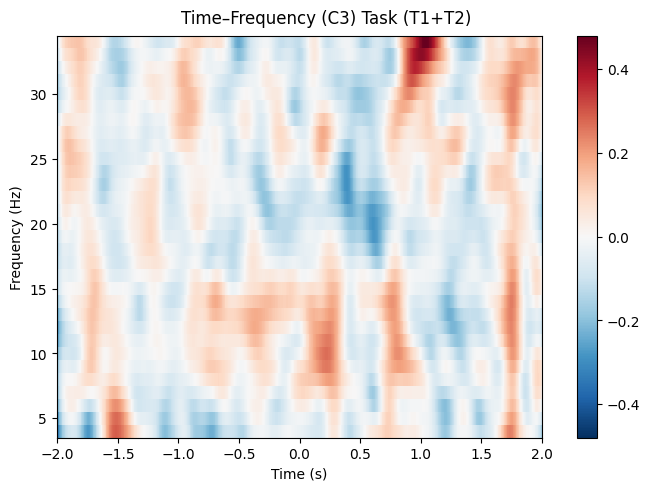

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


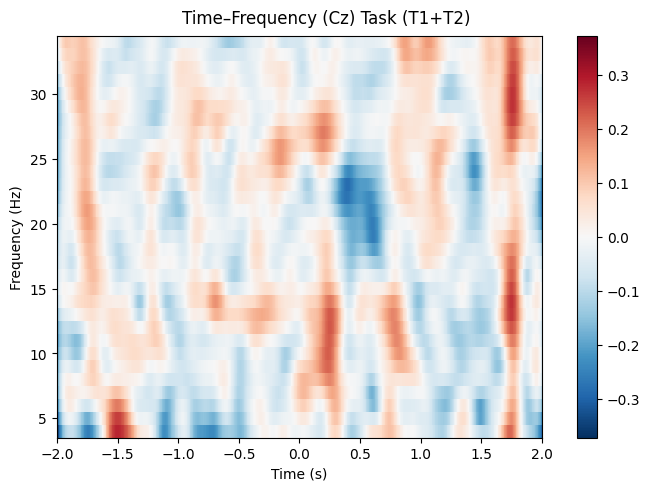

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


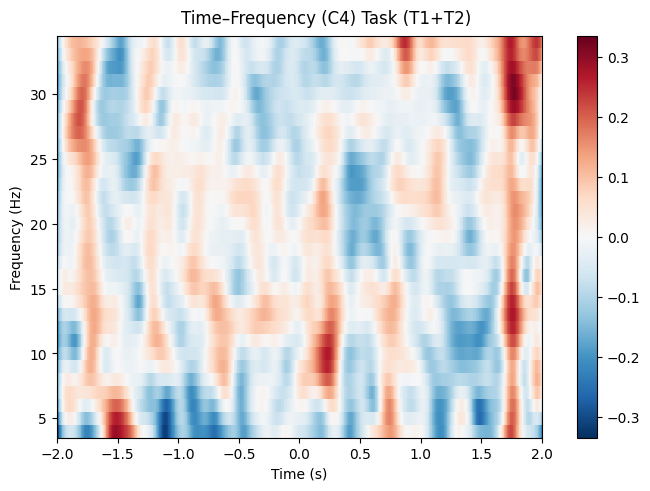

[<Figure size 640x480 with 2 Axes>]

In [9]:
# C3
power = mne.time_frequency.tfr_morlet(
    all_epochs_task[0].copy().pick(["C3"]),
    freqs=np.arange(4, 35, 1),
    n_cycles=np.arange(4, 35, 1) / 2,
    return_itc=False,
    average=True
)
power.data = np.mean([mne.time_frequency.tfr_morlet(all_epochs_task[i].copy().pick(["C3"]), freqs=np.arange(4, 35, 1), n_cycles=np.arange(4, 35, 1) / 2, return_itc=False, average=True).data for i in range(len(subjects))], axis=0)
power.plot(baseline=(-2, -1), mode="logratio", title="Time–Frequency (C3) Task (T1+T2)")

# Cz
power = mne.time_frequency.tfr_morlet(
    all_epochs_task[0].copy().pick(["Cz"]),
    freqs=np.arange(4, 35, 1),
    n_cycles=np.arange(4, 35, 1) / 2,
    return_itc=False,
    average=True
)
power.data = np.mean([mne.time_frequency.tfr_morlet(all_epochs_task[i].copy().pick(["Cz"]), freqs=np.arange(4, 35, 1), n_cycles=np.arange(4, 35, 1) / 2, return_itc=False, average=True).data for i in range(len(subjects))], axis=0)
power.plot(baseline=(-2, -1), mode="logratio", title="Time–Frequency (Cz) Task (T1+T2)")

# C4
power = mne.time_frequency.tfr_morlet(
    all_epochs_task[0].copy().pick(["C4"]),
    freqs=np.arange(4, 35, 1),
    n_cycles=np.arange(4, 35, 1) / 2,
    return_itc=False,
    average=True
)
power.data = np.mean([mne.time_frequency.tfr_morlet(all_epochs_task[i].copy().pick(["C4"]), freqs=np.arange(4, 35, 1), n_cycles=np.arange(4, 35, 1) / 2, return_itc=False, average=True).data for i in range(len(subjects))], axis=0)
power.plot(baseline=(-2, -1), mode="logratio", title="Time–Frequency (C4) Task (T1+T2)")

## ERD Computation (Mu and Beta)

We compute ERD as the percent decrease in band power during a task window relative to baseline:

$$
ERD = \frac{P_{baseline} - P_{task}}{P_{baseline}} \times 100
$$

Baseline window: **−2 to −1 s**  
Task window: **0 to 1 s**

In [10]:
def bandpower(epochs_obj, fmin, fmax, tmin, tmax, roi=("C3", "Cz", "C4")):
    ep = epochs_obj.copy().pick(list(roi)).crop(tmin=tmin, tmax=tmax)
    psd = ep.compute_psd(method="welch", fmin=fmin, fmax=fmax)
    return psd.get_data().mean(axis=(1, 2))  # one value per epoch

base_win = (-2.0, -1.0)
task_win = (0.0, 1.0)

mu_base = np.concatenate([bandpower(all_epochs_task[i], 8, 12, *base_win) for i in range(len(subjects))])
mu_task = np.concatenate([bandpower(all_epochs_task[i], 8, 12, *task_win) for i in range(len(subjects))])

beta_base = np.concatenate([bandpower(all_epochs_task[i], 13, 30, *base_win) for i in range(len(subjects))])
beta_task = np.concatenate([bandpower(all_epochs_task[i], 13, 30, *task_win) for i in range(len(subjects))])

erd_mu = ((mu_base.mean() - mu_task.mean()) / mu_base.mean()) * 100
erd_beta = ((beta_base.mean() - beta_task.mean()) / beta_base.mean()) * 100

print(f"ERD mu (8-12 Hz): {erd_mu:.2f}%")
print(f"ERD beta (13-30 Hz): {erd_beta:.2f}%")

Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
Effective window size : 1.006 (s)
ERD mu (8-12 Hz): 1.54%
ERD beta (13-30 Hz): 10.30%


## Statistical Test: Baseline vs Task Bandpower

We run paired t-tests comparing baseline vs task bandpower within epochs for mu and beta bands.
This provides a quantitative check that the ERD effect is statistically reliable.

In [11]:
from scipy.stats import ttest_rel

t_mu = ttest_rel(mu_base, mu_task)
t_beta = ttest_rel(beta_base, beta_task)

print("Mu band paired t-test:", t_mu)
print("Beta band paired t-test:", t_beta)

Mu band paired t-test: TtestResult(statistic=0.13795157055876062, pvalue=0.89059032640208, df=89)
Beta band paired t-test: TtestResult(statistic=1.716615653366799, pvalue=0.08952798751908239, df=89)


## Discussion / Interpretation

**Observed result:**  
The analysis revealed decreases in oscillatory power within the mu (8–12 Hz) and beta (13–30 Hz) bands during the motor task relative to baseline. These reductions are consistent with the expected direction of event-related desynchronization (ERD) in sensorimotor cortex.

**Statistical analysis:**  
Although the direction of the effect matched the ERD hypothesis, the paired t-tests did not reach conventional statistical significance. This suggests that the data show a trend consistent with ERD, but the effect is not strong enough to be considered statistically reliable with the current sample size.

**Interpretation:**  
The signal processing pipeline successfully captured neural patterns associated with motor activity. However, because the analysis used a limited number of subjects and scalp EEG is inherently noisy, the results should be interpreted as preliminary evidence of ERD rather than definitive confirmation.

**Limitations:**  
This analysis is limited by the small sample size, possible inter-subject variability, and the noisy nature of scalp EEG recordings.

**Future work:**  
Future analyses could include more subjects, additional runs, or spatial filtering approaches such as Common Spatial Patterns (CSP) to strengthen the sensorimotor signal and improve statistical power.